# The Hidden Mathematics of Storytelling (Week 3)

I've always been interested in folklore and mythology. Many stories, even from very different cultures, seem to follow similar patterns in how they unfold.

One explanation for this comes from the folklorist Vladimir Propp, who proposed that fairy tales are built from recurring narrative functions such as a villain appearing, a hero leaving home, receiving help, facing trials, and eventually returning or being rewarded.

This made me wonder whether storytelling might have an underlying structure that can be explored computationally.

I decided to analyse the Grimm Brothers’ fairy tales as a dataset, looking for patterns in the motifs and narrative events that appear across stories.

Dataset source: Kaggle

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
from collections import Counter

## Preparing the Dataset

Before doing any analysis, I first explored the dataset and did some basic preprocessing.

The dataset contains the title and full text of each story. I started by checking the structure of the dataset and removing an unnecessary index column that came with the CSV file.

I also calculated the text length of each story, mainly to get a rough sense of the size of the dataset.

In [156]:
df = pd.read_csv("grimms_fairytales.csv")
df.head()

,Unnamed: 0,Title,Text
0,0,THE GOLDEN BIRD,"A certain king had a beautiful garden, and in ..."
1,1,HANS IN LUCK,Some men are born to good luck: all they do or...
2,2,JORINDA AND JORINDEL,"There was once an old castle, that stood in th..."
3,3,THE TRAVELLING MUSICIANS,An honest farmer had once an ass that had been...
4,4,OLD SULTAN,"A shepherd had a faithful dog, called Sultan, ..."


In [157]:
# removing unnecessary index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,Title,Text
0,THE GOLDEN BIRD,"A certain king had a beautiful garden, and in ..."
1,HANS IN LUCK,Some men are born to good luck: all they do or...
2,JORINDA AND JORINDEL,"There was once an old castle, that stood in th..."
3,THE TRAVELLING MUSICIANS,An honest farmer had once an ass that had been...
4,OLD SULTAN,"A shepherd had a faithful dog, called Sultan, ..."


In [158]:
# total number of stories
print("Number of stories:", len(df))

# checking columns
print("Columns:", df.columns)

Number of stories: 63
Columns: Index(['Title', 'Text'], dtype='object')


In [159]:
# calculating word length of each story
df["text_length"] = df["Text"].apply(len)

df[["Title", "text_length"]].head()

,Title,text_length
0,THE GOLDEN BIRD,12488
1,HANS IN LUCK,11746
2,JORINDA AND JORINDEL,5877
3,THE TRAVELLING MUSICIANS,6909
4,OLD SULTAN,4377


## Cleaning the Text

Before analysing the language in the stories, the text needed some cleaning.

Right now words like:

King

king

king,

would all be treated as different words, even though they refer to the same thing.

To avoid this, I did two preprocessing steps:

-converting all text to lowercase

-removing punctuation and special characters

In [160]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_text"] = df["Text"].apply(clean_text)

df[["Title","clean_text"]].head()

,Title,clean_text
0,THE GOLDEN BIRD,a certain king had a beautiful garden and in t...
1,HANS IN LUCK,some men are born to good luck all they do or ...
2,JORINDA AND JORINDEL,there was once an old castle that stood in the...
3,THE TRAVELLING MUSICIANS,an honest farmer had once an ass that had been...
4,OLD SULTAN,a shepherd had a faithful dog called sultan wh...


I also removed stopwords(common filler words such as the, and, is) using the NLTK stopword list so the analysis focuses more on meaningful words.

In [161]:
!pip install nltk

In [162]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/priyalpatel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [163]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

In [164]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

filtered_words = []

for tokens in df["tokens"]:
    for word in tokens:
        if word not in stop_words:
            filtered_words.append(word)

word_counts_filtered = Counter(filtered_words)

common_words_filtered = pd.DataFrame(
    word_counts_filtered.most_common(20),
    columns=["word","count"]
)

common_words_filtered

,word,count
0,said,1162
1,came,461
2,went,441
3,one,401
4,little,391
5,away,291
6,go,276
7,king,270
8,would,265
9,could,260


## Trial 1: Detecting Narrative Motifs

Looking only at individual words is not very useful for understanding storytelling structure. Instead, I grouped related words into broader narrative motifs.

For example:

king, queen, prince, princess → royalty

witch, spell, enchanted → magic

wolf, horse, bird → animals

This allows the stories to be analysed in terms of recurring narrative elements, rather than just vocabulary.

For each story I counted how many times words related to each motif appear.

This gave a rough measure of how strongly each motif appears within the story.

In [165]:
motifs = {
    "royalty": ["king","queen","prince","princess","kingdom"],
    "magic": ["magic","spell","enchanted","fairy","witch"],
    "forest": ["forest","woods"],
    "animals": ["wolf","horse","bird","dog","cat"],
    "family": ["mother","father","daughter","son","brother","sister"],
    "journey": ["road","journey","travel","wander","path"],
    "death": ["dead","death","kill","killed"],
    "gold": ["gold","treasure","silver"]
}

for motif, words in motifs.items():
    df[motif] = df["clean_text"].apply(
        lambda text: int(any(word in text for word in words))
    )

df.head()

,Title,Text,text_length,clean_text,tokens,royalty,magic,forest,animals,family,journey,death,gold
0,THE GOLDEN BIRD,"A certain king had a beautiful garden, and in ...",12488,a certain king had a beautiful garden and in t...,"[a, certain, king, had, a, beautiful, garden, ...",1,0,0,1,1,1,1,1
1,HANS IN LUCK,Some men are born to good luck: all they do or...,11746,some men are born to good luck all they do or ...,"[some, men, are, born, to, good, luck, all, th...",1,0,0,1,1,1,1,1
2,JORINDA AND JORINDEL,"There was once an old castle, that stood in th...",5877,there was once an old castle that stood in the...,"[there, was, once, an, old, castle, that, stoo...",1,1,0,1,1,1,0,0
3,THE TRAVELLING MUSICIANS,An honest farmer had once an ass that had been...,6909,an honest farmer had once an ass that had been...,"[an, honest, farmer, had, once, an, ass, that,...",1,1,0,1,0,1,0,0
4,OLD SULTAN,"A shepherd had a faithful dog, called Sultan, ...",4377,a shepherd had a faithful dog called sultan wh...,"[a, shepherd, had, a, faithful, dog, called, s...",1,0,0,1,0,0,1,0


In [166]:
motif_counts = {}

for motif, words in motifs.items():
    df[motif + "_count"] = df["tokens"].apply(
        lambda tokens: sum(token in words for token in tokens)
    )

df.head()

,Title,Text,text_length,clean_text,tokens,royalty,magic,forest,animals,family,...,death,gold,royalty_count,magic_count,forest_count,animals_count,family_count,journey_count,death_count,gold_count
0,THE GOLDEN BIRD,"A certain king had a beautiful garden, and in ...",12488,a certain king had a beautiful garden and in t...,"[a, certain, king, had, a, beautiful, garden, ...",1,0,0,1,1,...,1,1,33,0,0,38,22,3,4,1
1,HANS IN LUCK,Some men are born to good luck: all they do or...,11746,some men are born to good luck all they do or ...,"[some, men, are, born, to, good, luck, all, th...",1,0,0,1,1,...,1,1,0,0,0,10,2,3,1,8
2,JORINDA AND JORINDEL,"There was once an old castle, that stood in th...",5877,there was once an old castle that stood in the...,"[there, was, once, an, old, castle, that, stoo...",1,1,0,1,1,...,0,0,0,9,0,2,0,1,0,0
3,THE TRAVELLING MUSICIANS,An honest farmer had once an ass that had been...,6909,an honest farmer had once an ass that had been...,"[an, honest, farmer, had, once, an, ass, that,...",1,1,0,1,0,...,0,0,0,1,0,18,0,3,0,0
4,OLD SULTAN,"A shepherd had a faithful dog, called Sultan, ...",4377,a shepherd had a faithful dog called sultan wh...,"[a, shepherd, had, a, faithful, dog, called, s...",1,0,0,1,0,...,1,0,0,0,0,18,0,0,1,0


## Trial 2: Motif Probabilities

Once the motifs were detected, I looked at how often each motif appears across the dataset.

The chart below shows the distribution of narrative motifs in the Grimm fairy tales.

In [167]:
motif_totals = {
    "royalty": df["royalty_count"].sum(),
    "magic": df["magic_count"].sum(),
    "forest": df["forest_count"].sum(),
    "animals": df["animals_count"].sum(),
    "family": df["family_count"].sum(),
    "journey": df["journey_count"].sum(),
    "death": df["death_count"].sum(),
    "gold": df["gold_count"].sum()
}

motif_totals

{'royalty': np.int64(546),
 'magic': np.int64(73),
 'forest': np.int64(89),
 'animals': np.int64(366),
 'family': np.int64(574),
 'journey': np.int64(65),
 'death': np.int64(144),
 'gold': np.int64(118)}

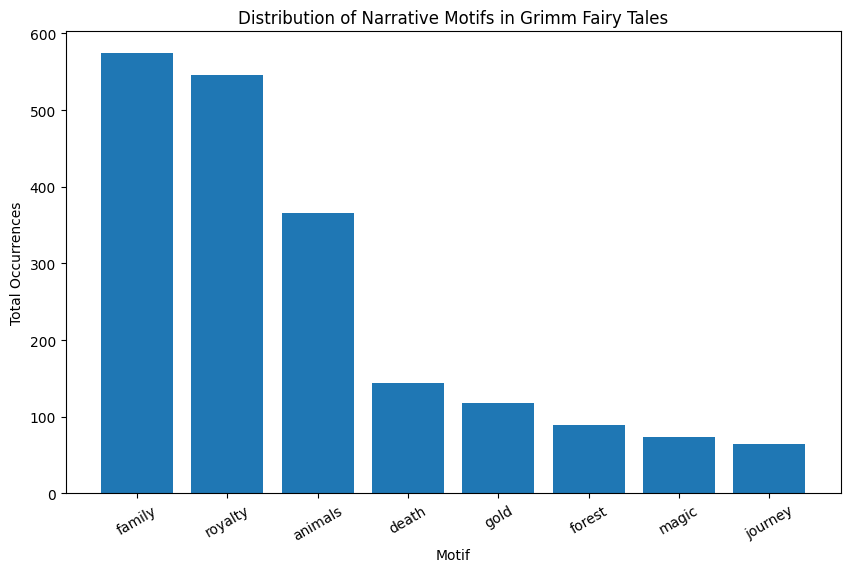

In [168]:
motif_totals_sorted = dict(sorted(motif_totals.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10,6))

plt.bar(motif_totals_sorted.keys(), motif_totals_sorted.values())

plt.title("Distribution of Narrative Motifs in Grimm Fairy Tales")
plt.xlabel("Motif")
plt.ylabel("Total Occurrences")

plt.xticks(rotation=30)

plt.show()

Motifs such as family relationships and royalty appear very frequently, which suggests that many of the stories revolve around domestic conflict, inheritance, and social hierarchies.

Each motif can be treated as a Bernoulli random variable, either it appears in a story or it does not. The bar chart above shows the probability of each motif appearing, equivalent to the p parameter in a Bernoulli distribution.

In [169]:
motif_columns = [
    "royalty_count", "magic_count", "forest_count",
    "animals_count", "family_count", "journey_count",
    "death_count", "gold_count"
]

motif_matrix = df[motif_columns]

## Trial 3: Conditional Probability Between Motifs

In the lecture, conditional probability was introduced using examples like:

P(Viral | 10K views)

I applied the same idea to narrative elements in fairy tales.

For example:

What is the probability that gold appears given that a story contains royalty?

What is the probability that animals appear given that a story takes place in a forest?

This can be written mathematically as:

P(A | B)

Instead of selecting just a few examples, I computed the conditional probability for every pair of motifs

In [170]:
binary_motifs = motif_matrix.copy()

for col in binary_motifs.columns:
    binary_motifs[col] = (binary_motifs[col] > 0).astype(int)

In [171]:
def conditional_probability(A, B):

    A_present = binary_motifs[A] == 1
    B_present = binary_motifs[B] == 1

    return (A_present & B_present).sum() / B_present.sum()

In [172]:
relations = []

for A in motif_columns:
    for B in motif_columns:
        if A != B:
            p = conditional_probability(A, B)
            relations.append((f"P({A.replace('_count','')} | {B.replace('_count','')})", p))

relations_df = pd.DataFrame(relations, columns=["relation","probability"])

In [173]:
top_relations = relations_df.sort_values("probability", ascending=False).head(12)

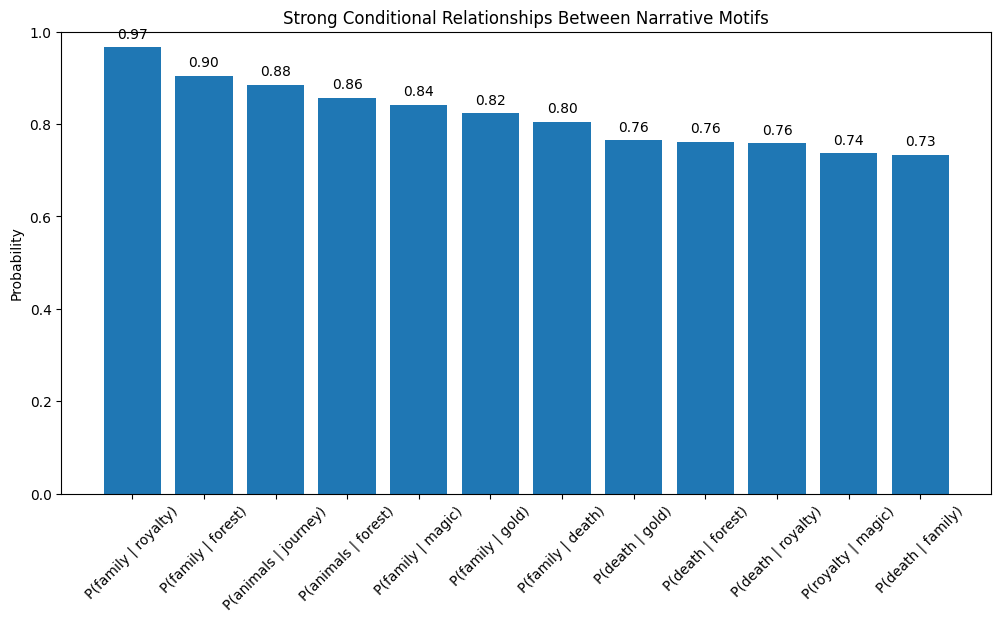

In [174]:
labels = top_relations["relation"]
values = top_relations["probability"]

plt.figure(figsize=(12,6))

bars = plt.bar(labels, values)

plt.ylabel("Probability")
plt.title("Strong Conditional Relationships Between Narrative Motifs")

plt.xticks(rotation=45)
plt.ylim(0,1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height+0.02, f"{height:.2f}", ha='center')

plt.show()

Some relationships were quite intuitive:

forests often imply animals

royalty frequently appears alongside treasure or gold

## Trial 4: Narrative Fingerprints of Stories

While motif counts show how frequently elements appear across the dataset, they don't show the structure of individual stories.

To visualize this, I represented each story as a radar chart, where each axis corresponds to a motif.

This produces a kind of narrative fingerprint for each story.

In [175]:
motif_columns = [
    "royalty_count",
    "magic_count",
    "forest_count",
    "animals_count",
    "family_count",
    "journey_count",
    "death_count",
    "gold_count"
]

labels = [m.replace("_count","") for m in motif_columns]

num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

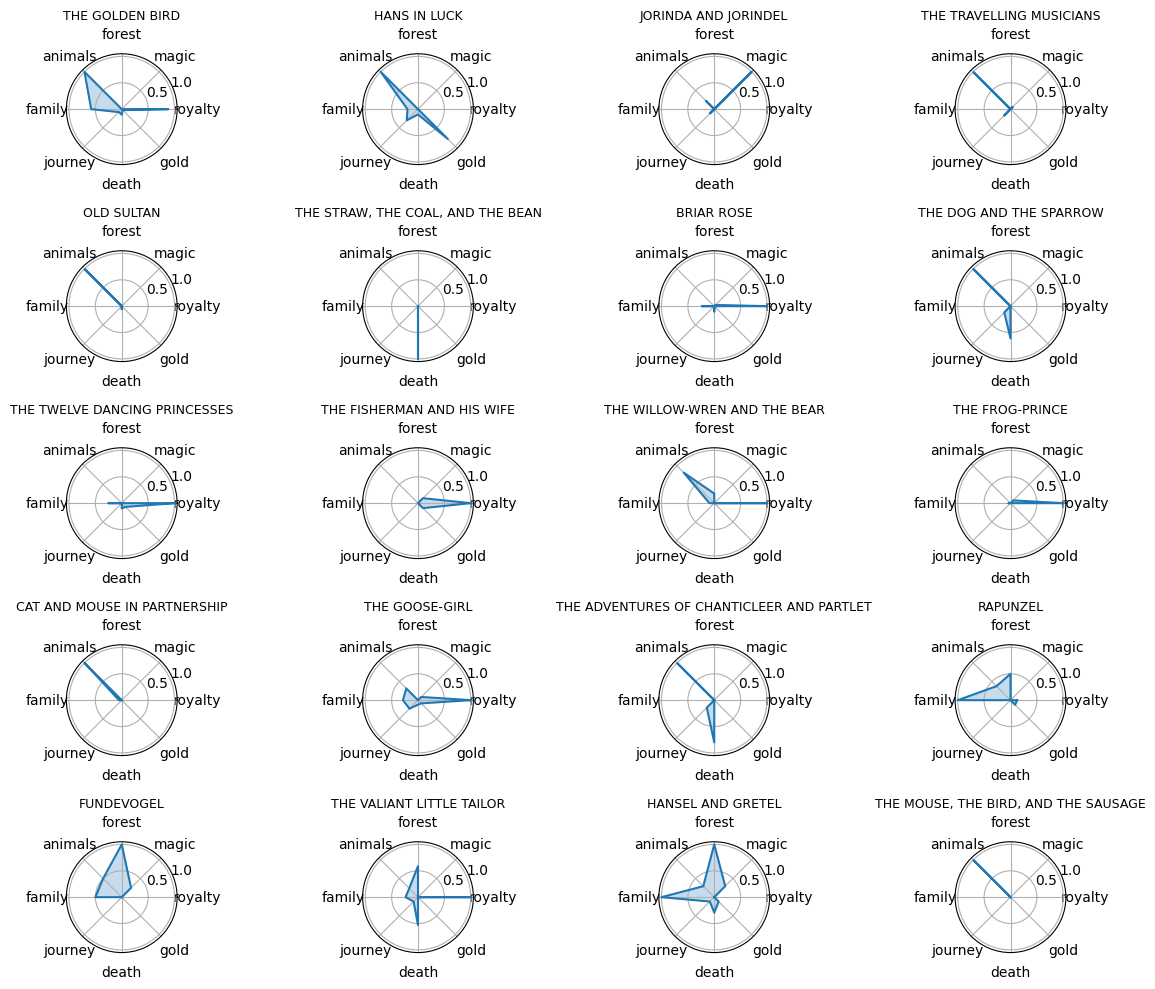

In [176]:
num_stories = 20

rows = int(np.ceil(np.sqrt(num_stories)))
cols = int(np.ceil(num_stories / rows))

plt.figure(figsize=(12,10))

for i in range(num_stories):

    values = df.iloc[i][motif_columns].values.astype(float)

    values = values / max(values.max(),1)

    values = np.concatenate((values,[values[0]]))

    ax = plt.subplot(rows, cols, i+1, polar=True)

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    ax.set_title(df.iloc[i]["Title"], fontsize=9)

plt.tight_layout()

plt.show()

Some stories have strong animal and forest themes, while others are dominated by royalty or family dynamics.

### The Average Grimm Fairy Tale
Out of curiosity, I also computed the average motif profile across all stories.

This produces a kind of "typical Grimm fairy tale".


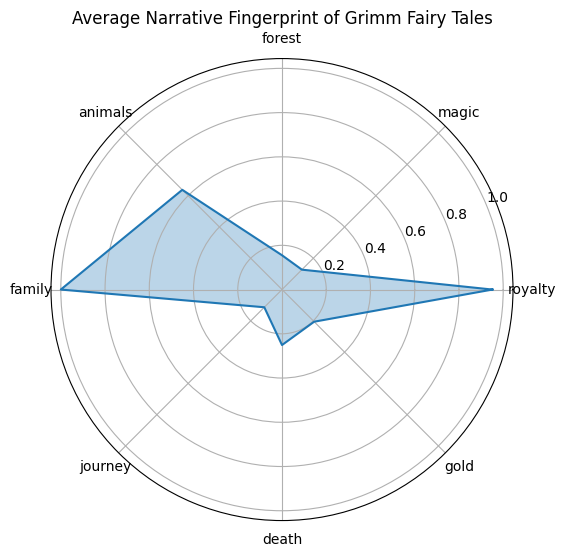

In [177]:
avg_values = df[motif_columns].mean()

values = avg_values.values
values = values / values.max()

values = np.concatenate((values,[values[0]]))

plt.figure(figsize=(6,6))

ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Average Narrative Fingerprint of Grimm Fairy Tales")

plt.show()

Ofcourse no individual story perfectly matches this shape, but it gives a sense of the overall narrative world of the dataset.

## Trial 5: Detecting Narrative Functions (Propp)

Motifs describe what appears in stories, but they don’t fully capture how stories unfold.

To explore narrative structure further, I looked at "Propp’s narrative functions"

Propp identified 31 recurring narrative events that appear across fairy tales, such as villainy, departure, struggle, victory and return. These events describe the structural progression of a story rather than just its themes.

Detecting all of these functions automatically from raw text is quite difficult, so I created a simplified version using keywords commonly found in the Grimm stories.

Using these keywords, I attempted to detect which narrative functions appear within each story and in what order.

In [178]:
propp_functions = [
"absentation",
"interdiction",
"violation",
"villainy",
"mediation",
"departure",
"receipt_magical_agent",
"guidance",
"struggle",
"victory",
"return",
"wedding"
]

In [179]:
function_keywords = {

"absentation": ["left","gone","away"],

"interdiction": ["warned","forbidden","told not"],

"violation": ["disobeyed","ignored"],

"villainy": ["witch","giant","dragon","devil","wolf"],

"mediation": ["heard","learned","discovered"],

"departure": ["journey","road","travel","wander"],

"receipt_magical_agent": ["magic","enchanted","spell"],

"guidance": ["guide","led","showed"],

"struggle": ["fight","battle","combat"],

"victory": ["defeated","won","overcame"],

"return": ["returned","came home"],

"wedding": ["married","wedding"]

}

In [180]:
def detect_propp_sequence(text):

    sequence = []

    for function, words in function_keywords.items():

        for word in words:

            if word in text:
                sequence.append(function)
                break

    return sequence


df["propp_sequence"] = df["clean_text"].apply(detect_propp_sequence)

df[["Title","propp_sequence"]].head()

,Title,propp_sequence
0,THE GOLDEN BIRD,"[absentation, mediation, departure, guidance, ..."
1,HANS IN LUCK,"[absentation, mediation, departure, guidance]"
2,JORINDA AND JORINDEL,"[absentation, mediation, departure, receipt_ma..."
3,THE TRAVELLING MUSICIANS,"[absentation, villainy, departure, guidance]"
4,OLD SULTAN,"[absentation, villainy, mediation, guidance, s..."


In [181]:
from collections import Counter

all_functions = []

for seq in df["propp_sequence"]:
    all_functions.extend(seq)

Counter(all_functions)

Counter({'guidance': 62,
         'absentation': 60,
         'mediation': 46,
         'departure': 36,
         'wedding': 28,
         'victory': 26,
         'villainy': 26,
         'return': 19,
         'receipt_magical_agent': 9,
         'struggle': 8,
         'interdiction': 3})

## Trial 6: Narrative Transition Probabilities

Once the narrative functions were detected, I wanted to see whether certain events tend to follow others.

If fairy tales follow recurring structural patterns, some narrative events should increase the likelihood of other events occurring afterwards.

To explore this, I computed a **transition matrix** that measures the probability that one narrative function follows another within the stories.

The transition matrix is built using conditional probabilities of the form:

P(B | A)

which represents the probability that event **B** occurs given that event **A** occurred previously.

This allowed me to model the stories as a kind of **probabilistic narrative structure**, where certain events naturally lead into others.

In [182]:
transition_counts = pd.DataFrame(
    0,
    index=propp_functions,
    columns=propp_functions
)

for seq in df["propp_sequence"]:

    for i in range(len(seq)-1):

        A = seq[i]
        B = seq[i+1]

        transition_counts.loc[A, B] += 1


transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

transition_matrix = transition_matrix.fillna(0)

transition_matrix


,absentation,interdiction,violation,villainy,mediation,departure,receipt_magical_agent,guidance,struggle,victory,return,wedding
absentation,0.0,0.05,0.0,0.400000,0.383333,0.066667,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000
interdiction,0.0,0.00,0.0,0.333333,0.333333,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000
violation,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
villainy,0.0,0.00,0.0,0.000000,0.846154,0.076923,0.000000,0.076923,0.000000,0.000000,0.000000,0.000000
mediation,0.0,0.00,0.0,0.000000,0.000000,0.630435,0.043478,0.326087,0.000000,0.000000,0.000000,0.000000
departure,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.200000,0.800000,0.000000,0.000000,0.000000,0.000000
receipt_magical_agent,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
guidance,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.186047,0.488372,0.232558,0.093023
struggle,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.625000,0.250000,0.125000
victory,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.388889,0.611111


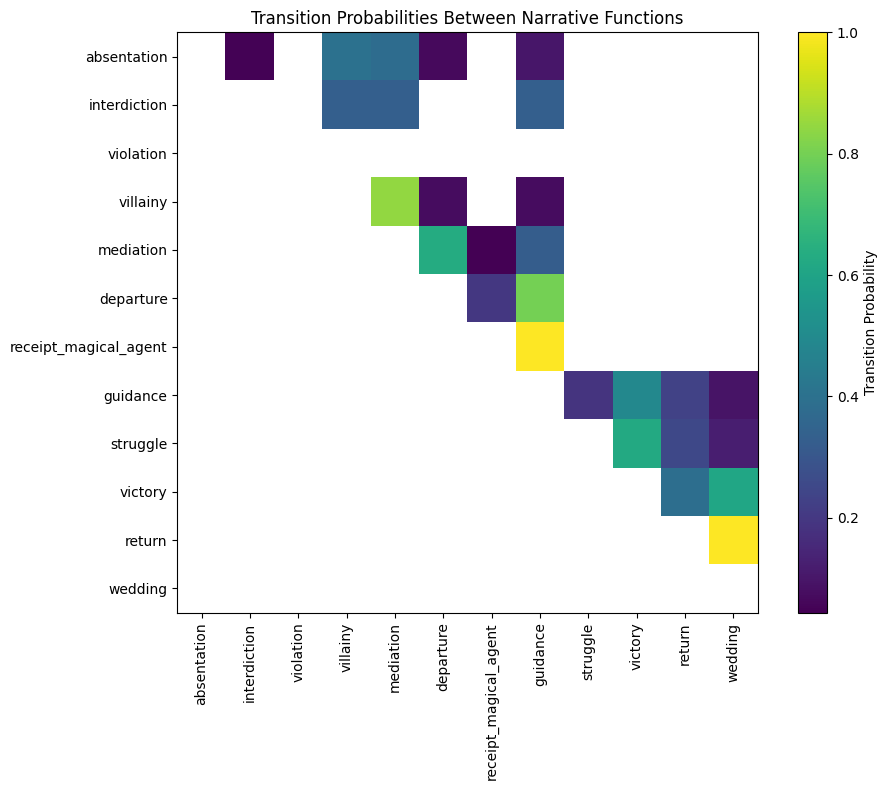

In [183]:
plt.figure(figsize=(10,8))

matrix = transition_matrix.replace(0, np.nan)

plt.imshow(matrix, cmap="viridis")

plt.colorbar(label="Transition Probability")

plt.xticks(range(len(propp_functions)), propp_functions, rotation=90)
plt.yticks(range(len(propp_functions)), propp_functions)

plt.title("Transition Probabilities Between Narrative Functions")

plt.tight_layout()

plt.show()

This suggests that fairy tales follow a kind of probabilistic narrative structure, where certain events tend to lead to others.

## Trial 7: Narrative Grammar as a Network

Reading the transition matrix directly was quite difficult, so I tried visualising it as a network graph using the NetworkX library.

In this graph:

nodes represent narrative functions

arrows represent transitions between events

thicker edges indicate stronger probabilities

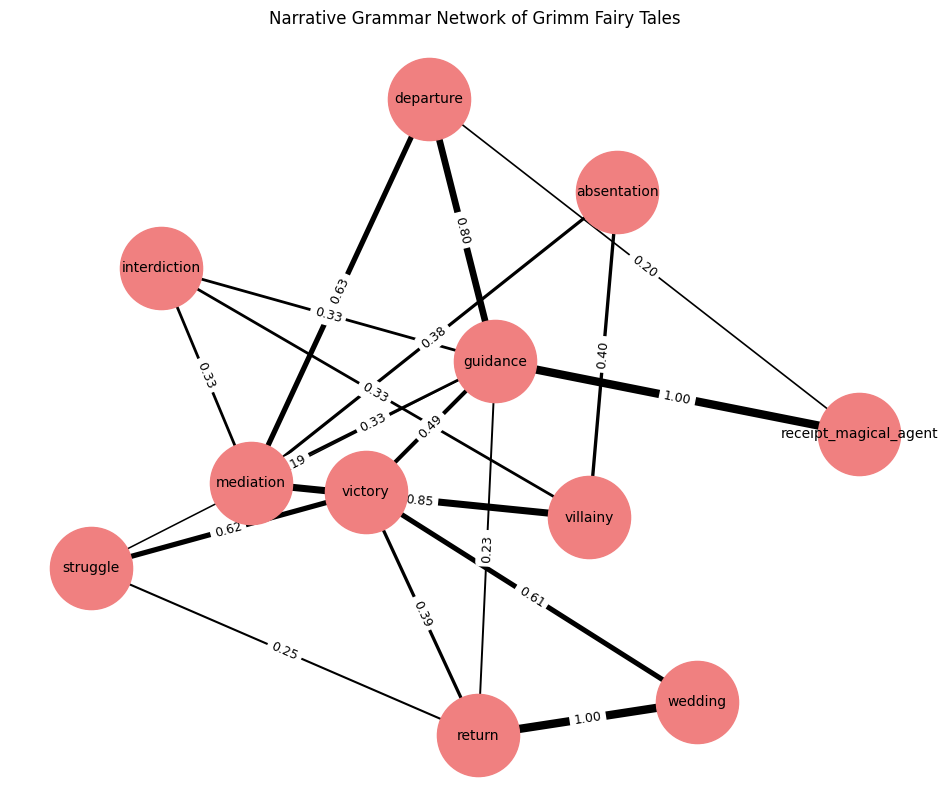

In [184]:
import networkx as nx

G = nx.DiGraph()

threshold = 0.15   # only show meaningful transitions

for i in transition_matrix.index:
    for j in transition_matrix.columns:
        
        weight = transition_matrix.loc[i,j]
        
        if weight > threshold:
            G.add_edge(i, j, weight=weight)

plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, seed=42, k=1.2)

edges = G.edges()
weights = [G[u][v]['weight']*6 for u,v in edges]

nx.draw_networkx_nodes(
    G, pos,
    node_size=3500,
    node_color="lightcoral"
)

nx.draw_networkx_labels(
    G, pos,
    font_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    width=weights,
    arrows=True,
    arrowstyle='-|>'
)

# edge labels(probabilities)
edge_labels = {(u,v): f"{d['weight']:.2f}" for u,v,d in G.edges(data=True)}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

plt.title("Narrative Grammar Network of Grimm Fairy Tales")

plt.axis("off")

plt.show()

This made it easier to see how stories tend to move between events.

## Trial 8: Generating Story Sequences

Finally, I used the transition probabilities to generate new story structures.

The generator begins with a starting event and samples the next event using the probabilities observed in the Grimm dataset.

For each narrative function it selects a sentence from the corresponding pool of Grimm story sentences.

At first glance the output might feel a bit like a random story generator, but technically it isn’t completely random. The sequence of events is guided by the transition probabilities learned from the Grimm stories, meaning each step in the narrative is influenced by the statistical structure of the dataset. So while the results can be a little chaotic, they are still loosely grounded in the underlying narrative patterns of the original tales

In [185]:
df["clean_text_full"] = df["Text"].apply(lambda x: x.replace("\n", " "))

In [186]:
df["sentences"] = df["clean_text_full"].apply(
    lambda x: re.split(r'[.!?]\s+', x)
)

In [187]:
function_sentences = {f: [] for f in function_keywords.keys()}

for sentences in df["sentences"]:
    
    for sentence in sentences:
        
        s = sentence.lower()
        
        for function, words in function_keywords.items():
            
            if any(word in s for word in words):
                
                cleaned = sentence.strip()
                
                if len(cleaned) > 40:   # avoid tiny fragments
                    function_sentences[function].append(cleaned)

In [188]:
import random

def generate_story():

    start_events = ["villainy","departure","mediation"]
    current = random.choice([e for e in start_events if e in function_sentences])

    story = []
    visited = set()
    steps = 0

    while current != "wedding" and steps < 12:

        if current in function_sentences and function_sentences[current]:

            sentence = random.choice(function_sentences[current])
            story.append(sentence)

        visited.add(current)

        probs = transition_matrix.loc[current].copy()

        for v in visited:
            if v in probs.index:
                probs[v] = 0

        if steps > 6 and "victory" in probs.index:
            probs["victory"] += 0.3

        if probs.sum() == 0:
            break

        next_event = random.choices(
            probs.index,
            weights=probs.values
        )[0]

        current = next_event
        steps += 1

    return ". ".join(story) + "."

In [189]:
for i in range(3):
    print(generate_story())
    print()

The giant, after he had dragged the heavy burden part of the way, could go no further, and cried: ‘Hark you, I shall have to let the tree fall!’ The tailor sprang nimbly down, seized the tree with both arms as if he had been carrying it, and said to the giant: ‘You are such a great fellow, and yet cannot even carry the tree!’  They went on together, and as they passed a cherry-tree, the giant laid hold of the top of the tree where the ripest fruit was hanging, bent it down, gave it into the tailor’s hand, and bade him eat. Next morning, to the astonishment of everyone, he came out again safe and unharmed, and said to the lord of the castle: ‘The dogs have revealed to me, in their own language, why they dwell there, and bring evil on the land. I asked her if my betrothed lived here, and she answered, “Ah, you poor child, you are come to a murderers’ den; your betrothed does indeed live here, but he will kill you without mercy and afterwards cook and eat you.”’  ‘My darling, this is only


The result is a probabilistic remix of the original stories.

Example output:

*Thus she went on and on, and journeyed till she came to the world’s end; then she came to the sun, but the sun looked much too hot and fiery; so she ran away quickly to the moon, but the moon was cold and chilly, and said, ‘I smell flesh and blood this way!’ so she took herself away in a hurry and came to the stars, and the stars were friendly and kind to her, and each star sat upon his own little stool; but the morning star rose up and gave her a little piece of wood, and said, ‘If you have not this little piece of wood, you cannot unlock the castle that stands on the glass-mountain, and there your brothers live.’ The little girl took the piece of wood, rolled it up in a little cloth, and went on again until she came to the glass-mountain, and found the door shut. When the widow heard that, she said joyfully to the cat:   ‘Now open the gates and doors all wide,   And carry old Mr Fox outside.’  But just as the wedding was going to be solemnized, old Mr Fox stirred under the bench, and cudgelled all the rabble, and drove them and Mrs Fox out of the house. The two strangers were all this time looking on, and did not know what to say for wonder.*




The story sounds… a little insane, but still strangely fairy-tale-like.

Part of the reason it feels chaotic is because the sentences come from completely different Grimm stories, so the narrative continuity breaks quite quickly. However, the underlying structure still loosely follows some of the patterns discovered earlier in the analysis. The sequence begins with a 'journey', moves into 'magical assistance', and eventually leads into 'conflict', which mirrors some of the transitions that appeared frequently in the transition matrix.

So while the story might feel like a random generator at first glance, the sequence of narrative events is actually guided by the "probabilistic relationships between story functions" learned from the dataset.

I had a little too much fun with this part to be honest.

## Reflection

This project started with a simple curiosity about whether fairy tales might follow hidden structural patterns, but while working with the dataset it quickly became clear that the possibilities for analysis are almost endless. Storytelling has been studied for centuries, and there are already many theories about narrative structure, from Vladimir Propp’s functions to Joseph Campbell’s Hero’s Journey, and even Kurt Vonnegut’s famously rejected thesis on story shapes...none of which I used directly, but all of which point to how long people have sensed there is structure here worth finding.


Exploring the Grimm fairy tales through data made me realise how many different directions this kind of analysis could take. There are countless narrative patterns, themes and structures that could be uncovered depending on the approach.

It was also a really satisfying experience working through the dataset and building the analysis step by step on my own. Even though the models here are quite simplified, they show how storytelling structures can be explored computationally.

If I continue this project further, I would definitely like to turn it into a data visualisation project, possibly combined with a story archetype generator that allows different narrative structures to be explored interactively.

## LLM Disclaimer

This was my first time working with a dataset that consisted entirely of text rather than numbers, so there were a few parts of the process where I needed help understanding how to approach certain tasks.

I used LLM's occasionally to help with things like implementing NLTK stopword removal, since I had not used the NLTK library before and wasn’t very familiar with its workflow. It also helped clarify how to structure parts of the motif counting and conditional probability calculations, and assisted with debugging small errors that came up while working through the notebook.

Some of the official documentation for these libraries can be quite technical, so the LLM explanations were mainly useful for translating those concepts into simpler steps that I could implement and understand.